<a href="https://colab.research.google.com/github/mrstarnge09/EV-Battery-SoH-Prediction/blob/main/EV_Battery_State_of_Health_(SoH)_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== Loading Dataset ===
Dataset Shape: (10000, 8)

First 5 rows:
   total_distance_km  average_trip_speed_kmph  ambient_temperature_C  \
0           15607.06                    34.95                  35.55   
1           38077.86                    33.32                  16.46   
2           29547.76                    27.05                  22.13   
3           24347.68                    44.29                  33.21   
4            7084.73                    39.06                  26.87   

   trip_duration_min  charging_cycles  fast_charging_ratio_%  \
0              61.05              270                  20.82   
1              46.74              685                  51.85   
2              87.16              533                  34.93   
3              27.52              438                  42.09   
4              57.03              113                   1.62   

   average_battery_temperature_C  battery_health_%  
0                          37.86             75.37  
1          

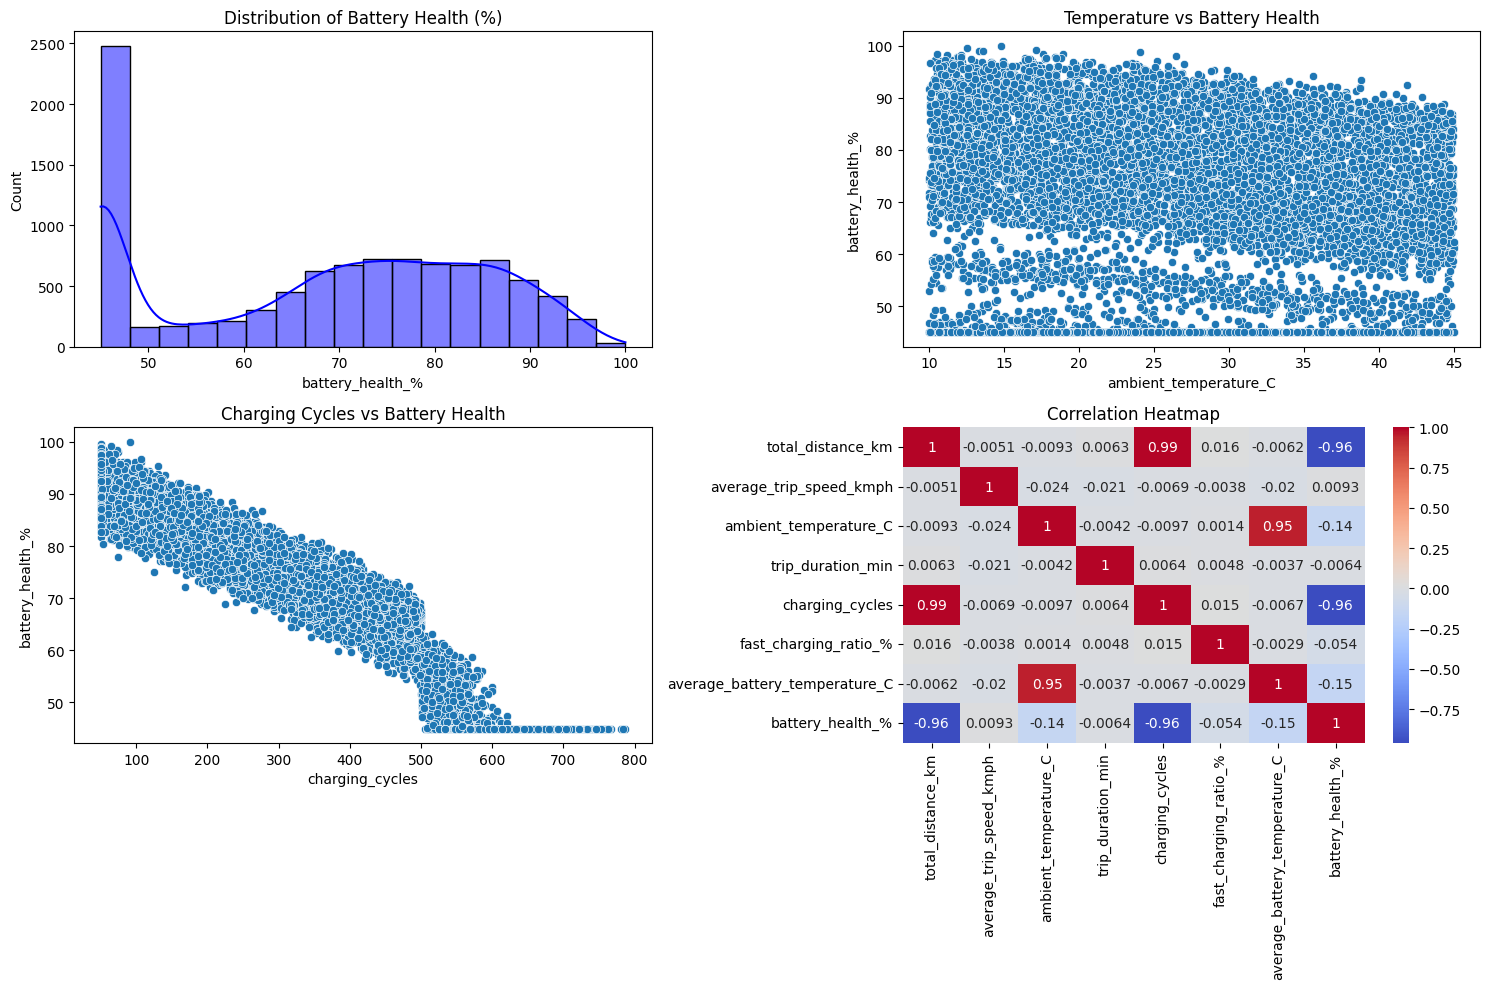

Data Preprocessing Completed!
=== Model Performance Comparison ===

🔹 Linear Regression Results:
MAE  : 2.9323
RMSE : 3.7000
R²   : 0.9502

🔹 Random Forest Results:
MAE  : 0.9889
RMSE : 1.4095
R²   : 0.9928

🔹 XGBoost Results:
MAE  : 1.0763
RMSE : 1.5257
R²   : 0.9915


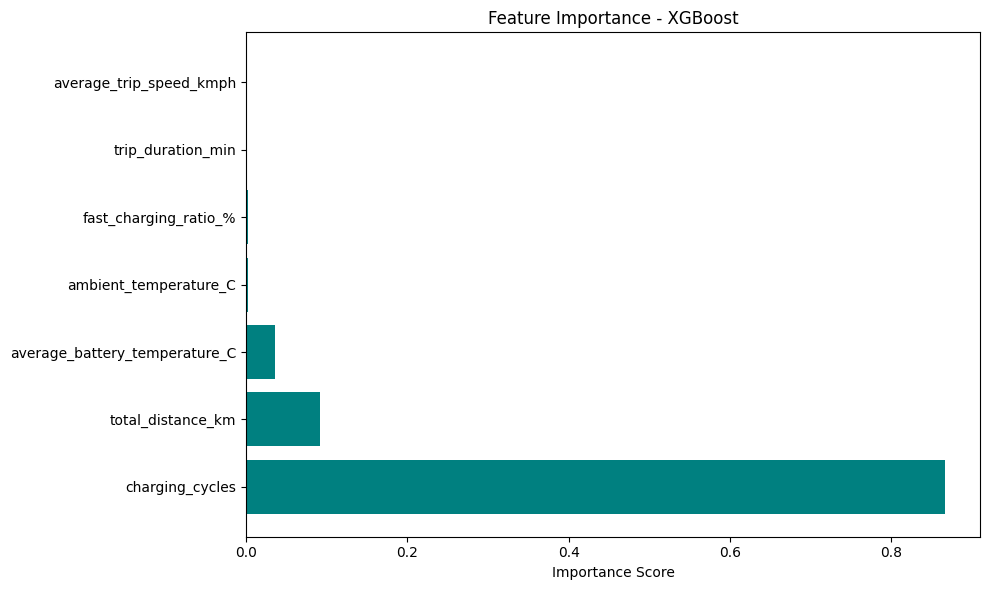


Final Model Comparison:
               Model     MAE    RMSE  R2 Score
0  Linear Regression  2.9323  3.7000    0.9502
1      Random Forest  0.9889  1.4095    0.9928
2            XGBoost  1.0763  1.5257    0.9915

✅ Best Model (XGBoost) and Scaler Saved Successfully!


In [ ]:
# =====================================================
# EV BATTERY STATE OF HEALTH (SoH) PREDICTION
# Full Code - Week 1 to Week 3
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ====================== WEEK 1: LOAD & EDA ======================

print("=== Loading Dataset ===")
# Change the filename as per your downloaded file
df = pd.read_csv('ev.csv')   # ← Update this name

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

# ====================== VISUALIZATIONS ======================

plt.figure(figsize=(15, 10))

# Distribution of Battery Health
plt.subplot(2, 2, 1)
sns.histplot(df['battery_health_%'], kde=True, color='blue')
plt.title('Distribution of Battery Health (%)')

# Temperature vs Battery Health
plt.subplot(2, 2, 2)
sns.scatterplot(x='ambient_temperature_C', y='battery_health_%', data=df)
plt.title('Temperature vs Battery Health')

# Charging Cycles vs Battery Health
plt.subplot(2, 2, 3)
sns.scatterplot(x='charging_cycles', y='battery_health_%', data=df)
plt.title('Charging Cycles vs Battery Health')

# Correlation Heatmap
plt.subplot(2, 2, 4)
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')

plt.tight_layout()
plt.show()

# ====================== WEEK 2: PREPROCESSING & MODELING ======================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Define features and target
X = df.drop('battery_health_%', axis=1)
y = df['battery_health_%']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data Preprocessing Completed!")

# ====================== TRAIN MODELS ======================

# Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
pred_lr = lr.predict(X_test_scaled)

# Random Forest
rf = RandomForestRegressor(random_state=42, n_estimators=100)
rf.fit(X_train_scaled, y_train)
pred_rf = rf.predict(X_test_scaled)

# XGBoost
xgb = XGBRegressor(random_state=42, n_estimators=100)
xgb.fit(X_train_scaled, y_train)
pred_xgb = xgb.predict(X_test_scaled)

# ====================== EVALUATION ======================

def evaluate_model(y_true, y_pred, model_name):
    print(f"\n🔹 {model_name} Results:")
    print(f"MAE  : {mean_absolute_error(y_true, y_pred):.4f}")
    print(f"RMSE : {mean_squared_error(y_true, y_pred)**0.5:.4f}")
    print(f"R²   : {r2_score(y_true, y_pred):.4f}")

print("=== Model Performance Comparison ===")
evaluate_model(y_test, pred_lr, "Linear Regression")
evaluate_model(y_test, pred_rf, "Random Forest")
evaluate_model(y_test, pred_xgb, "XGBoost")

# ====================== WEEK 3: FEATURE IMPORTANCE ======================

plt.figure(figsize=(10, 6))
feature_importance = xgb.feature_importances_
features = X.columns

indices = feature_importance.argsort()[::-1]
plt.barh(features[indices], feature_importance[indices], color='teal')
plt.title('Feature Importance - XGBoost')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

# ====================== MODEL COMPARISON TABLE ======================

results = {
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'MAE': [mean_absolute_error(y_test, pred_lr),
            mean_absolute_error(y_test, pred_rf),
            mean_absolute_error(y_test, pred_xgb)],
    'RMSE': [mean_squared_error(y_test, pred_lr)**0.5,
             mean_squared_error(y_test, pred_rf)**0.5,
             mean_squared_error(y_test, pred_xgb)**0.5],
    'R2 Score': [r2_score(y_test, pred_lr),
                 r2_score(y_test, pred_rf),
                 r2_score(y_test, pred_xgb)]
}

comparison_df = pd.DataFrame(results)
print("\nFinal Model Comparison:")
print(comparison_df.round(4))

# ====================== SAVE MODEL ======================

import joblib

joblib.dump(xgb, 'ev_battery_soh_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("\n✅ Best Model (XGBoost) and Scaler Saved Successfully!")

In [ ]:
!pip install streamlit
!streamlit run app.py

In [ ]:
# app.py
import streamlit as st
import pandas as pd
import joblib
import numpy as np

# Load model and scaler
model = joblib.load('ev_battery_soh_model.pkl')
scaler = joblib.load('scaler.pkl')

st.title("⚡ EV Battery State of Health Predictor")
st.write("Predict how healthy your EV battery is")

# Sidebar
st.sidebar.header("Input Battery Parameters")

# Input fields (change feature names according to your dataset)
temperature = st.sidebar.slider("Temperature (°C)", 0, 60, 25)
charging_cycles = st.sidebar.number_input("Charging Cycles", 0, 3000, 500)
voltage = st.sidebar.slider("Voltage (V)", 2.5, 4.5, 3.7)
current = st.sidebar.slider("Current (A)", -100, 100, 10)
soc = st.sidebar.slider("State of Charge (%)", 0, 100, 50)

# Create input dataframe
input_data = pd.DataFrame({
    'temperature': [temperature],
    'charging_cycles': [charging_cycles],
    'voltage': [voltage],
    'current': [current],
    'soc': [soc]
    # Add other features from your dataset here
})

# Predict
if st.button("Predict Battery Health"):
    input_scaled = scaler.transform(input_data)
    prediction = model.predict(input_scaled)[0]

    st.success(f"**Predicted Battery Health: {prediction:.2f}%**")

    # Health Status
    if prediction >= 85:
        st.success("🟢 Battery is in Excellent Condition")
    elif prediction >= 70:
        st.warning("🟡 Battery is in Good Condition")
    else:
        st.error("🔴 Battery needs attention / replacement soon")

st.caption("Built as part of EV Battery SoH Prediction Project")

2026-05-26 13:59:35.061 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-26 13:59:35.062 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-26 13:59:35.066 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-26 13:59:35.068 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-26 13:59:35.070 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-26 13:59:35.071 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-26 13:59:35.073 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-26 13:59:35.075 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()

In [27]:
%%writefile app.py

import streamlit as st
import pandas as pd
import joblib
import numpy as np

# Load model and scaler
model = joblib.load('ev_battery_soh_model.pkl')
scaler = joblib.load('scaler.pkl')

st.set_page_config(page_title="EV Battery Predictor", page_icon="⚡")

st.title("⚡ EV Battery State of Health Predictor")
st.markdown("### Predict the remaining health of an Electric Vehicle Battery")

st.sidebar.header("🔧 Enter Battery Parameters")

# Input fields - aligned with training data features
total_distance_km = st.sidebar.number_input("Total Distance (km)", min_value=1000.0, max_value=40000.0, value=20000.0, step=100.0)
average_trip_speed_kmph = st.sidebar.slider("Average Trip Speed (km/h)", min_value=20.0, max_value=60.0, value=40.0, step=0.1)
ambient_temperature_C = st.sidebar.slider("Ambient Temperature (°C)", min_value=10.0, max_value=45.0, value=27.5, step=0.1)
trip_duration_min = st.sidebar.slider("Trip Duration (min)", min_value=10.0, max_value=90.0, value=50.0, step=0.1)
charging_cycles = st.sidebar.number_input("Charging Cycles", min_value=50, max_value=800, value=370)
fast_charging_ratio_percent = st.sidebar.slider("Fast Charging Ratio (%)", min_value=0.0, max_value=90.0, value=28.7, step=0.1)
average_battery_temperature_C = st.sidebar.slider("Average Battery Temperature (°C)", min_value=25.0, max_value=50.0, value=35.3, step=0.1)


if st.button("🔮 Predict Battery Health"):
    input_data = pd.DataFrame({
        'total_distance_km': [total_distance_km],
        'average_trip_speed_kmph': [average_trip_speed_kmph],
        'ambient_temperature_C': [ambient_temperature_C],
        'trip_duration_min': [trip_duration_min],
        'charging_cycles': [charging_cycles],
        'fast_charging_ratio_%': [fast_charging_ratio_percent],
        'average_battery_temperature_C': [average_battery_temperature_C]
    })

    input_scaled = scaler.transform(input_data)
    prediction = model.predict(input_scaled)[0]

    st.success(f"**Predicted Battery Health: {prediction:.2f}%**")

    if prediction >= 85:
        st.success("🟢 Excellent Condition")
    elif prediction >= 70:
        st.warning("🟡 Good Condition")
    else:
        st.error("🔴 Poor Condition")

Overwriting app.py


In [ ]:
!streamlit run app.py & npx localtunnel --port 8501

In [29]:
import os
!pip install pyngrok -q

from pyngrok import ngrok
import threading

# Kill any existing tunnels
ngrok.kill()

# --- FIX: Add your ngrok authtoken here --- #
# 1. Go to https://dashboard.ngrok.com/signup
# 2. Sign up and get your authtoken from https://dashboard.ngrok.com/get-started/your-authtoken
# 3. Replace 'YOUR_AUTHTOKEN' with your actual token
ngrok.set_auth_token("2xavdel36STnYYhWW5iWfq9iYBv_2Pxc6RPtUU6N9ascm9Ha4")
# ---------------------------------------- #

# Start Streamlit in background
os.system('streamlit run app.py --server.port 8501 --server.headless true &')

# Create ngrok tunnel
public_url = ngrok.connect(8501)
print("🚀 Your Streamlit App is Live!")
print(public_url)

🚀 Your Streamlit App is Live!
NgrokTunnel: "https://4455-34-132-250-37.ngrok-free.app" -> "http://localhost:8501"
